In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler


In [53]:
columns = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

customers_df = pd.read_csv('../DataFrames/Mall_Customers.csv', usecols=columns)

customers_df.dropna(inplace=True)
customers_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


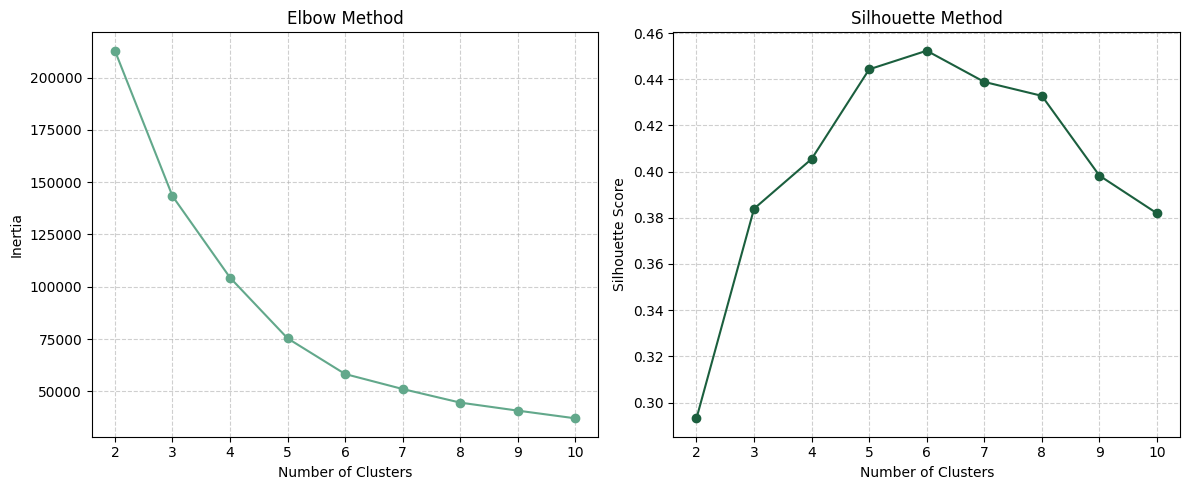

Optimal number of clusters based on silhouette method: 6


In [56]:
# Assuming customers_df is already loaded

# Define range for clusters
cluster_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customers_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(customers_df, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cluster_range, inertia, marker='o', color='#62a88b', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='o', color='#1b5f3e', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Determine best cluster count
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
print(f'Optimal number of clusters based on silhouette method: {optimal_clusters}')


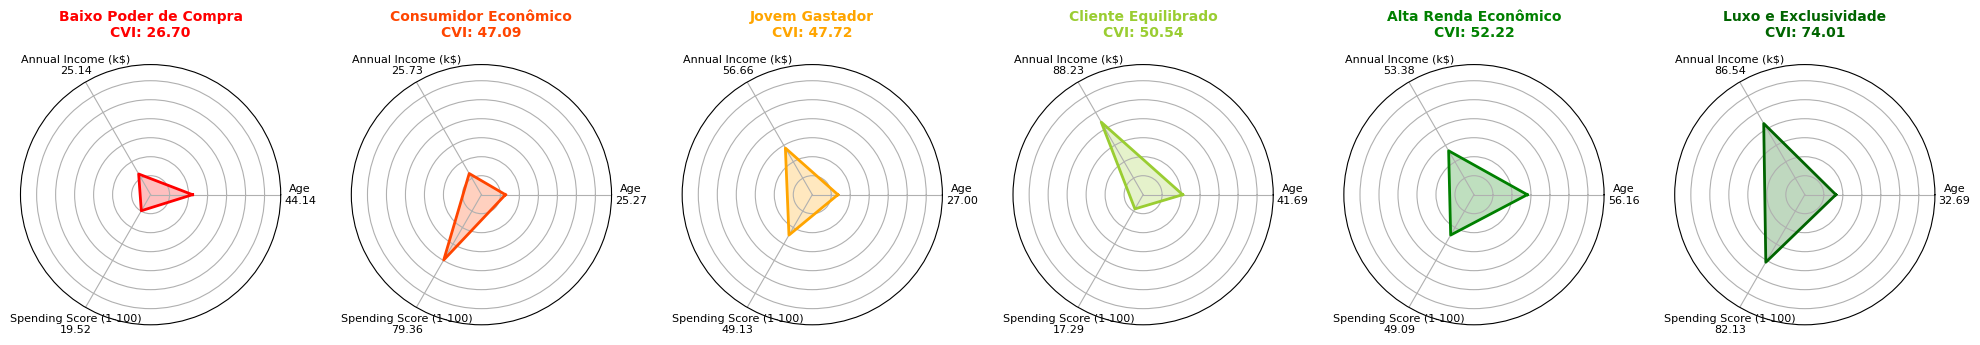


Tabela de Valores, CVI e Porcentagem de Cada Perfil:
                         Age  Annual Income (k$)  Spending Score (1-100)  CVI Médio     %
Baixo Poder de Compra  44.14               25.14                   19.52      26.70  10.5
Consumidor Econômico   25.27               25.73                   79.36      47.09  11.0
Jovem Gastador         27.00               56.66                   49.13      47.72  19.0
Cliente Equilibrado    41.69               88.23                   17.29      50.54  17.5
Alta Renda Econômico   56.16               53.38                   49.09      52.22  22.5
Luxo e Exclusividade   32.69               86.54                   82.13      74.01  19.5


In [62]:
# Definição das colunas e rótulos na ordem correta
columns = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Seleção dos dados sem normalização
X = customers_df[columns].to_numpy()

# Cálculo do Índice de Valor do Cliente (CVI)
weights = np.array([0.2, 0.4, 0.4])  # Pesos para idade, renda e pontuação de gastos
CVI = np.dot(X, weights)

# Aplicação do KMeans com 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_

# Obtendo a média das notas por cluster
cluster_means = []
mean_scores = []  # Lista para armazenar as médias gerais dos clusters
cluster_counts = []  # Contagem de clientes por cluster
CVI_means = []  # Média do CVI por cluster

for i in range(6):
    cluster_data = X[labels == i]
    mean_values = cluster_data.mean(axis=0)
    cluster_means.append(mean_values)
    mean_scores.append(mean_values[1:].mean())  # Média considerando apenas renda e pontuação de gastos
    cluster_counts.append(len(cluster_data))  # Número de clientes no cluster
    CVI_means.append(CVI[labels == i].mean())  # Média do CVI por cluster

# Ordenando os clusters do pior para o melhor com base no CVI
sorted_indices = np.argsort(CVI_means)  # Ordenando os índices pelo CVI
cluster_means_sorted = [cluster_means[i] for i in sorted_indices]
mean_scores_sorted = [mean_scores[i] for i in sorted_indices]
cluster_counts_sorted = [cluster_counts[i] for i in sorted_indices]
CVI_means_sorted = [CVI_means[i] for i in sorted_indices]

# Definição dos perfis em português
profile_names = [
    "Baixo Poder de Compra", "Consumidor Econômico", "Jovem Gastador",
    "Cliente Equilibrado", "Alta Renda Econômico", "Luxo e Exclusividade"
]

# Cálculo da porcentagem de cada perfil
total_customers = sum(cluster_counts)
percentages_sorted = [(count / total_customers) * 100 for count in cluster_counts_sorted]

# Definindo cores manualmente para os clusters (do pior para o melhor)
manual_colors = ['red', 'orangered', 'orange', 'yellowgreen', 'green', 'darkgreen']
cluster_colors_sorted = [manual_colors[i] for i in range(6)]

# Definição dos ângulos para o radar
angles = np.linspace(0, 2 * np.pi, len(columns), endpoint=False).tolist()
angles += angles[:1]  # Fechando o gráfico

# Criando a figura principal
fig, axes = plt.subplots(1, 6, figsize=(20, 4), subplot_kw=dict(polar=True))

# Criando gráficos de radar para cada cluster
for i, ax in enumerate(axes.flat):  
    # Obtendo os valores médios do cluster atual
    values = cluster_means_sorted[i].tolist()
    values += values[:1]  # Fechando o gráfico

    # Plotando o gráfico de radar com cor baseada na média do cluster
    ax.plot(angles, values, linewidth=2, linestyle='solid', color=cluster_colors_sorted[i])
    ax.fill(angles, values, alpha=0.25, color=cluster_colors_sorted[i])

    # Configurando os limites para manter a mesma escala entre os gráficos
    ax.set_ylim(0, X[:, 1:].max())  # Garantindo escala uniforme

    # Definindo os rótulos para as áreas do conhecimento com as médias
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f"{label}\n{cluster_means_sorted[i][j]:.2f}" for j, label in enumerate(columns)], fontsize=8)

    # Removendo etiquetas do eixo radial
    ax.set_yticklabels([])

    # Definindo título do cluster
    ax.set_title(f'{profile_names[i]}\nCVI: {CVI_means_sorted[i]:.2f}', size=10, color=cluster_colors_sorted[i], weight='bold', pad=20)

# Ajustando o layout dos gráficos
plt.tight_layout()
plt.show()

# Tabela com os valores, CVI e porcentagem de cada perfil
print("\nTabela de Valores, CVI e Porcentagem de Cada Perfil:")

# Criando um DataFrame com os valores médios
table_data = np.array(cluster_means_sorted)
table_data = np.round(table_data, 2)  # Arredondando para 2 casas decimais

# Adicionando o CVI médio e a porcentagem de cada perfil
CVI_column = np.round(CVI_means_sorted, 2).reshape(-1, 1)
percentage_column = np.round(percentages_sorted, 1).reshape(-1, 1)  # Arredondando para 1 casa decimal

table_data = np.hstack([table_data, CVI_column, percentage_column])

# Criando DataFrame para exibição
df_table = pd.DataFrame(table_data, columns=columns + ["CVI Médio", "%"], index=profile_names)

# Imprimindo a tabela
print(df_table.to_string(index=True))
